In [ ]:
from matplotlib import pyplot as plt
from functions import *

# BV and Ru(bpy)3 stock solutions now made in pH 6 buffer
# mixing limitations in cuvette, colour gradient seen

# V(Ru(bpy)3, 1 mM, buffer) = 200 ul, V(EDTA, saturated, buffer) = 1 ml, made up to 3 ml pH 6 buffer
# V(BV, 1 mM, buffer) in ul used and start times for each run, start time adjusted slightly to begin at linear region

XV = r"[BV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[BV$^{2\!+\!}$]$_0$" # [XV2+]0

runs = [(300, "11-46-40-000"), # 11-46-26-000 recorded start time
        (600, "12-21-16-000"), # 12-21-16-000
        (900, "12-55-19-000"), # 12-55-19-000
        (1200, "13-36-05-000"), # 13-36-05-000
        (1500, "14-12-42-000"), # 14-12-42-000
        (1800, "16-40-13-000")] # 16-40-13-000

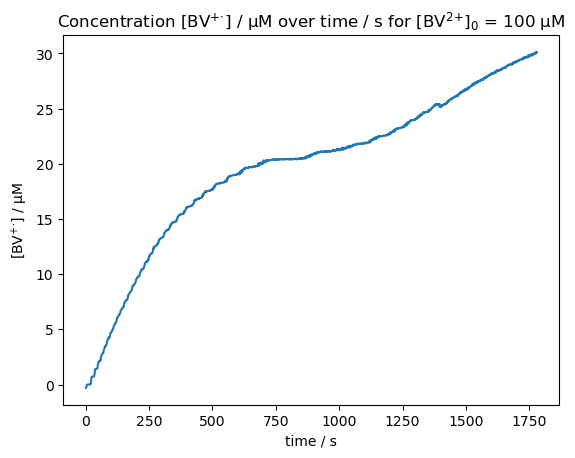

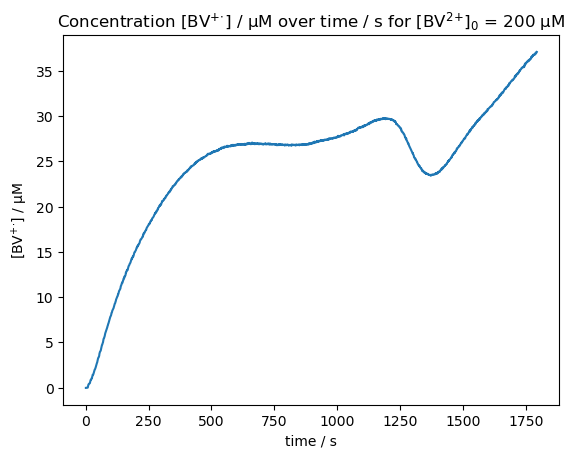

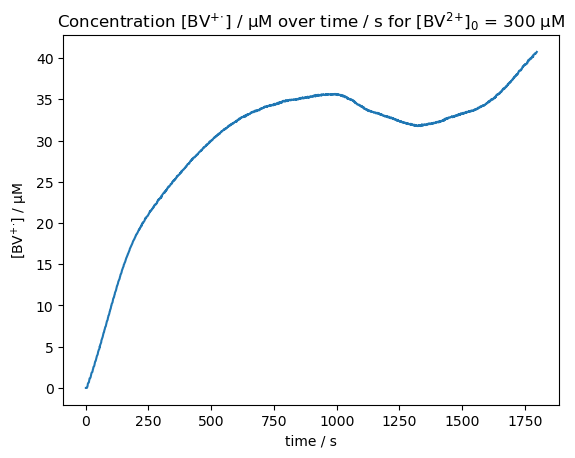

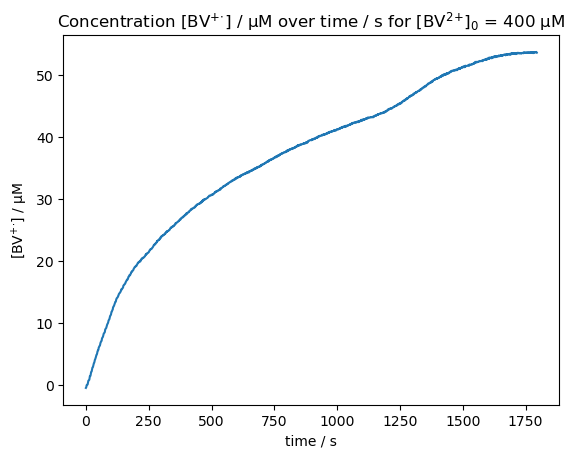

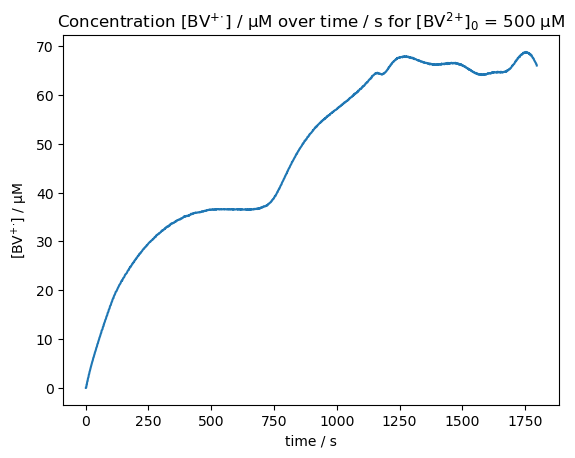

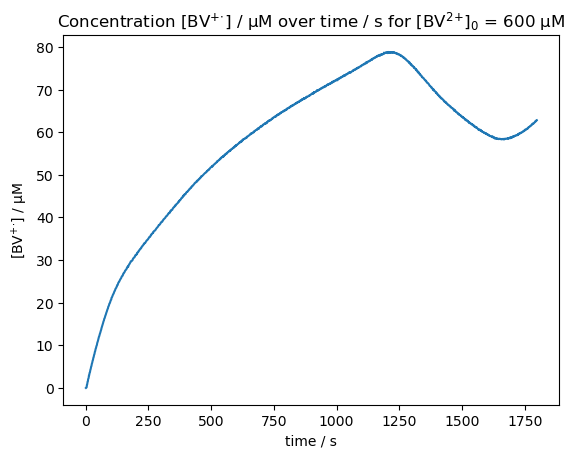

In [ ]:
# concentration vs time plot for each run
for (v, start) in runs:
    data = f'./results/260701_Rubpy_BV_EDTA_Buffered/Rubpy_BV_{v}_EDTA_Buffered'
    t, c = concvstime(data, 540, 1e-2, 1.4e6, start=start, duration=30*60)
    c0 = solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3) # initial XV2+ concentration
    plt.plot(t, [conc*1e6 for conc in c]) # plot time in seconds, concentrations in μM
    plt.xlabel(r'time / s')
    plt.ylabel(rf'{XV} / μM')
    plt.title(rf'Concentration {XV} / μM over time / s for {XV0} = {c0*1e6:.0f} μM')
    plt.show()

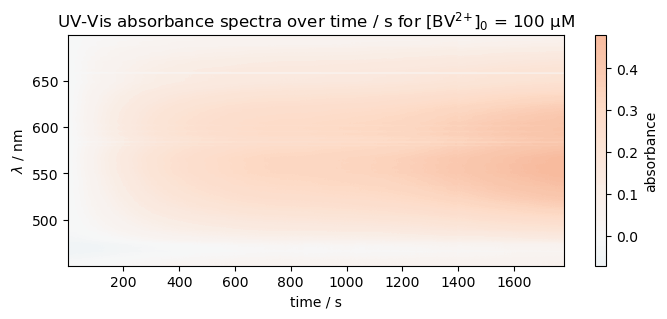

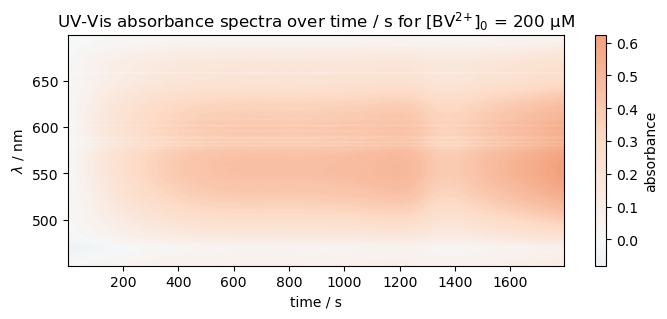

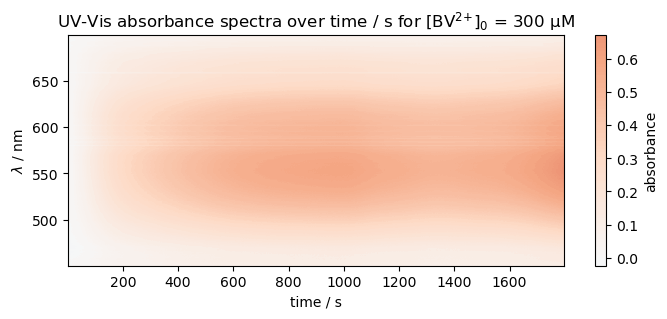

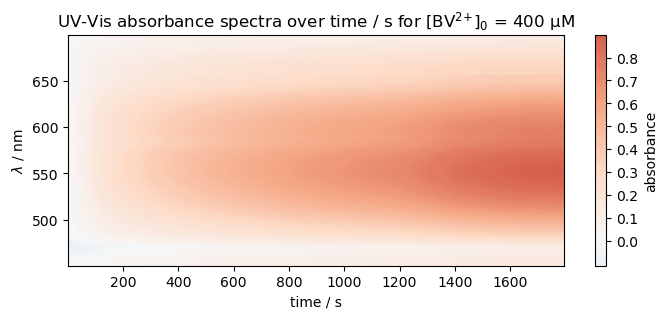

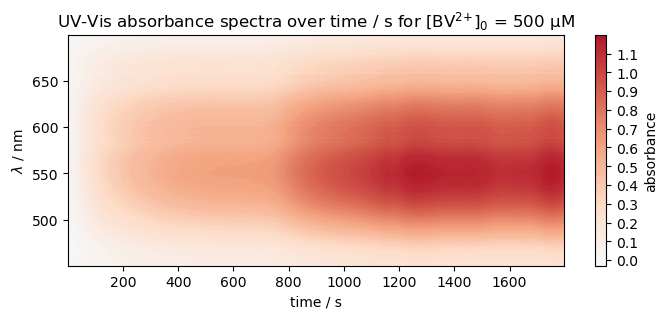

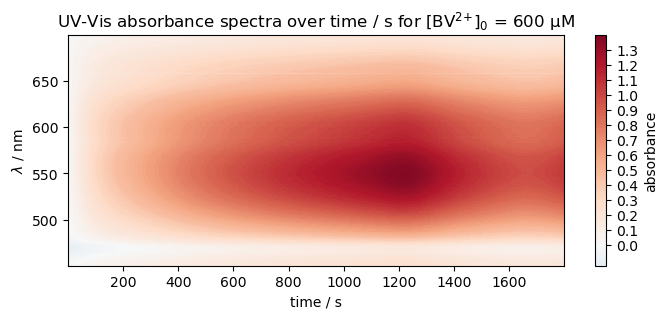

In [ ]:
# uv-vis absorption spectrum over time for each run
for (v, start) in runs:
    data = f'./results/260701_Rubpy_BV_EDTA_Buffered/Rubpy_BV_{v}_EDTA_Buffered'
    c0 = solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3) # initial XV2+ concentration

    t, l, a = spectrumvstime(data, start=start, duration=30*60)
    mask = (l >= 450) & (l <= 700) 
    a = a[mask, :]
    l = l[mask]

    fig, ax = plt.subplots(figsize=(8,3))
    cf = ax.contourf(t, l, a, levels=100, vmin=-1.5, vmax=1.5, cmap="RdBu_r")
    ax.set_title(rf"UV-Vis absorbance spectra over time / s for {XV0} = {c0*1e6:.0f} μM")
    ax.set_xlabel("time / s")
    ax.set_ylabel(r'$\lambda$ / nm')
    cbar = plt.colorbar(cf)
    cbar.set_label("absorbance")
    cbar.set_ticks(np.arange(0, a.max(), 0.1))
    plt.show()

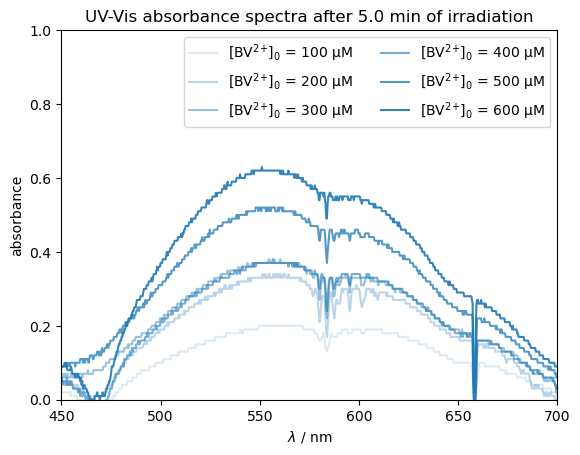

In [ ]:
# uv-vis absorption spectrum at time t for each run
t = 5*60
for (v, start) in runs:
    data = f'./results/260701_Rubpy_BV_EDTA_Buffered/Rubpy_BV_{v}_EDTA_Buffered'
    c0 = solprop(cstock=1e-3, valiquot=v*1e-6, vsol=3e-3) # initial XV2+ concentration
    l, a = spectrumvstimepoints(data, [t], start=start)
    plt.plot(l, a[0], color="#1F77B4", alpha=v/2000, label=rf'{XV0} = {c0*1e6:.0f} μM')
plt.xlim(450, 700)
plt.ylim(0,1)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.title(f'UV-Vis absorbance spectra after {t/60} min of irradiation')
plt.legend(ncols=2)
plt.show()